# <center><font color='red'>STATISTICS PRACTICAL ADVANCED 2 ASSIGNMENT</h3></font></center>

#  <span style="color:green">1. Write a Python program to perform a Z-test for comparing a sample mean to a known population mean and interpret the results.</span>

In [2]:
import numpy as np
import scipy.stats as stats

def z_test(sample_data, population_mean, population_std):
    sample_mean = np.mean(sample_data)
    sample_size = len(sample_data)
    z = (sample_mean - population_mean) / (population_std / np.sqrt(sample_size))
    p_value = 1 - stats.norm.cdf(z)
    return z, p_value




In [3]:
# Example
np.random.seed(0)
sample = np.random.normal(loc=52, scale=10, size=30)
z_stat, p_val = z_test(sample, population_mean=50, population_std=10)
print("Z-statistic:", z_stat)
print("P-value:", p_val)

Z-statistic: 3.5210697740367065
P-value: 0.00021490475208663096


#  <span style="color:green">2.  Simulate random data to perform hypothesis testing and calculate the corresponding P-value using Python.</span>

In [4]:
def simulate_and_test():
    sample = np.random.normal(loc=100, scale=15, size=50)
    population_mean = 95
    population_std = 15
    z_stat, p_value = z_test(sample, population_mean, population_std)
    return z_stat, p_value

z, p = simulate_and_test()
print("Simulated Z-statistic:", z)
print("Simulated P-value:", p)


Simulated Z-statistic: 0.13259532263532242
Simulated P-value: 0.44725671587672067


#  <span style="color:green">3.  Implement a one-sample Z-test using Python to compare the sample mean with the population mean.</span>

In [5]:
def one_sample_z_test(sample, pop_mean, pop_std):
    z_stat = (np.mean(sample) - pop_mean) / (pop_std / np.sqrt(len(sample)))
    p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))
    return z_stat, p_value




In [6]:
# Example:
sample_data = np.random.normal(loc=105, scale=20, size=40)
z_val, p_val = one_sample_z_test(sample_data, pop_mean=100, pop_std=20)
print("One-sample Z-test Z-statistic:", z_val)
print("One-sample Z-test P-value:", p_val)

One-sample Z-test Z-statistic: 4.483602534579727
One-sample Z-test P-value: 7.33933115082408e-06


#  <span style="color:green">4.  Perform a two-tailed Z-test using Python and visualize the decision region on a plot.</span>

In [7]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

def two_tailed_z_test(sample, pop_mean, pop_std, alpha=0.05):
    z_stat = (np.mean(sample) - pop_mean) / (pop_std / np.sqrt(len(sample)))
    p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))

    x = np.linspace(-4, 4, 1000)
    y = stats.norm.pdf(x, 0, 1)
    critical = stats.norm.ppf(1 - alpha/2)

    plt.plot(x, y, color="orange", label="Standard Normal Distribution")
    plt.fill_between(x, y, where=(x <= -critical) | (x >= critical), color='red', alpha=0.3, label="Rejection Region")
    plt.axvline(z_stat, color='blue', linestyle='--', label=f"Z = {z_stat:.2f}")
    plt.title("Two-tailed Z-test Decision Region")
    plt.legend()
    plt.grid(True)
    plt.show()

    return z_stat, p_value



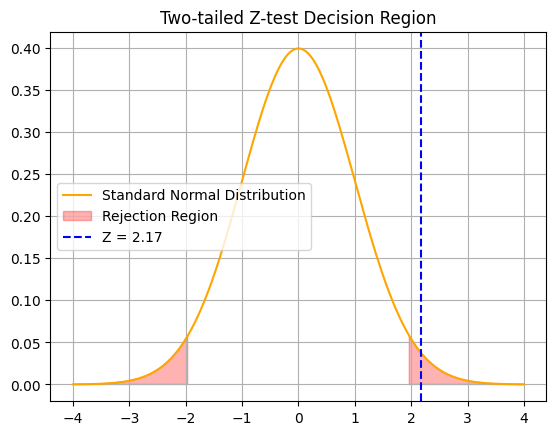

Z-statistic: 2.171561836269104
P-value: 0.02988872824202793


In [8]:
# Example:
sample_data = np.random.normal(loc=103, scale=10, size=30)
z, p = two_tailed_z_test(sample_data, pop_mean=100, pop_std=10)
print("Z-statistic:", z)
print("P-value:", p)


#  <span style="color:green">5.  Create a Python function that calculates and visualizes Type 1 and Type 2 errors during hypothesis testing.</span>

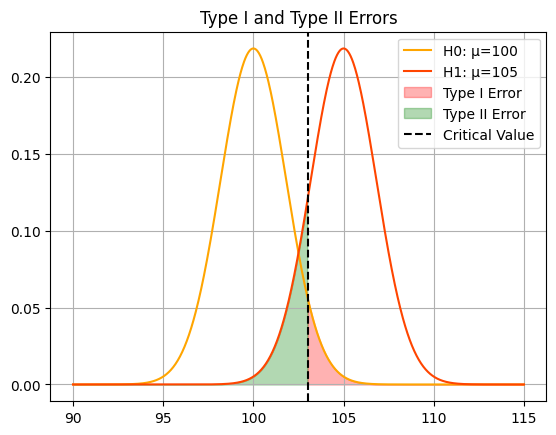

In [10]:
def visualize_type_errors(mu0=100, mu1=105, std=10, n=30, alpha=0.05):
    se = std / np.sqrt(n)
    critical_val = stats.norm.ppf(1 - alpha, loc=mu0, scale=se)
    
    x = np.linspace(90, 115, 1000)
    y0 = stats.norm.pdf(x, loc=mu0, scale=se)
    y1 = stats.norm.pdf(x, loc=mu1, scale=se)

    plt.plot(x, y0, label="H0: μ=100", color='orange')
    plt.plot(x, y1, label="H1: μ=105", color='orangered')
    plt.fill_between(x, y0, where=(x >= critical_val), color='red', alpha=0.3, label="Type I Error")
    plt.fill_between(x, y1, where=(x < critical_val), color='green', alpha=0.3, label="Type II Error")
    plt.axvline(critical_val, color='black', linestyle='--', label="Critical Value")
    plt.title("Type I and Type II Errors")
    plt.legend()
    plt.grid(True)
    plt.show()

visualize_type_errors()


#  <span style="color:green">6.  Write a Python program to perform an independent T-test and interpret the results.</span>

In [12]:
def independent_t_test(sample1, sample2):
    t_stat, p_value = stats.ttest_ind(sample1, sample2, equal_var=False)
    return t_stat, p_value

# Example 
group1 = np.random.normal(loc=100, scale=15, size=30)
group2 = np.random.normal(loc=105, scale=15, size=30)
t, p = independent_t_test(group1, group2)
print("T-statistic:", t)
print("P-value:", p)


T-statistic: -0.47887413933214273
P-value: 0.6338503706827998


#  <span style="color:green">7. Perform a paired sample T-test using Python and visualize the comparison results.</span>

In [14]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

def paired_t_test(sample1, sample2):
    t_stat, p_value = stats.ttest_rel(sample1, sample2)
    
    plt.figure(figsize=(8, 4))
    plt.plot(sample1, label='Sample 1', marker='o', color='orange')
    plt.plot(sample2, label='Sample 2', marker='x', color='orangered')
    plt.title('Paired Sample Comparison')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    return t_stat, p_value


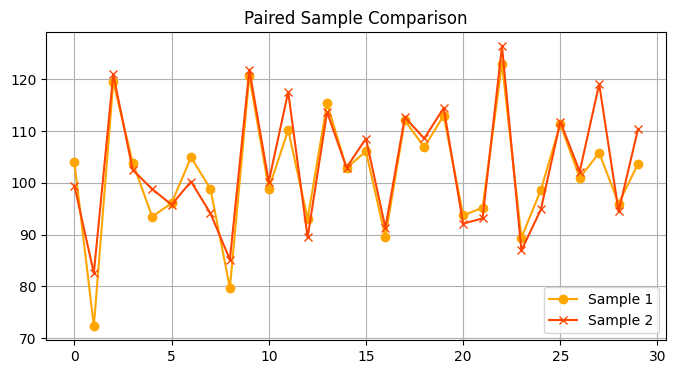

T-statistic: -1.3909480439731936
P-value: 0.1748223896602023


In [15]:
# Example 
before = np.random.normal(100, 10, size=30)
after = before + np.random.normal(2, 5, size=30)
t_stat, p_val = paired_t_test(before, after)
print("T-statistic:", t_stat)
print("P-value:", p_val)

#  <span style="color:green">8.  Simulate data and perform both Z-test and T-test, then compare the results using Python.</span>

In [16]:
def compare_z_t_tests():
    sample = np.random.normal(loc=100, scale=15, size=30)
    pop_mean = 95
    pop_std = 15

    # Z-test
    z_stat = (np.mean(sample) - pop_mean) / (pop_std / np.sqrt(len(sample)))
    z_p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))

    # T-test
    t_stat, t_p_value = stats.ttest_1samp(sample, pop_mean)

    print("Z-test -> Z-statistic:", z_stat, ", P-value:", z_p_value)
    print("T-test -> T-statistic:", t_stat, ", P-value:", t_p_value)

compare_z_t_tests()


Z-test -> Z-statistic: 0.10895786095176344 , P-value: 0.9132359133685874
T-test -> T-statistic: 0.10880963874521685 , P-value: 0.914102888550465


#  <span style="color:green">9.   Write a Python function to calculate the confidence interval for a sample mean and explain its significance.</span>


In [17]:
def confidence_interval(sample, confidence=0.95):
    n = len(sample)
    mean = np.mean(sample)
    se = stats.sem(sample)
    h = se * stats.t.ppf((1 + confidence) / 2., n - 1)
    return (mean - h, mean + h)


In [18]:
# Example 
sample = np.random.normal(100, 15, size=30)
ci = confidence_interval(sample)
print("95% Confidence Interval for Mean:", ci)

95% Confidence Interval for Mean: (np.float64(91.5082539084001), np.float64(101.94661047199305))


#  <span style="color:green">10.Write a Python program to calculate the margin of error for a given confidence level using sample data.</span>

In [19]:
import numpy as np
import scipy.stats as stats

def margin_of_error(sample, confidence=0.95):
    n = len(sample)
    se = stats.sem(sample)
    z_score = stats.norm.ppf((1 + confidence) / 2)
    moe = z_score * se
    return moe


In [20]:
# Example
sample_data = np.random.normal(100, 15, 50)
print("Margin of Error:", margin_of_error(sample_data))


Margin of Error: 4.0781135410358065


#  <span style="color:green">11. Implement a Bayesian inference method using Bayes' Theorem in Python and explain the process.</span>

In [21]:
def bayes_theorem(prior_A, prob_B_given_A, prob_B):
    return (prob_B_given_A * prior_A) / prob_B

# Example
# P(Disease) = 0.01, P(Positive | Disease) = 0.99, P(Positive) = 0.05
posterior = bayes_theorem(0.01, 0.99, 0.05)
print("Posterior Probability:", posterior)


Posterior Probability: 0.198


#  <span style="color:green">12.  Perform a Chi-square test for independence between two categorical variables in Python.</span>

In [22]:
import pandas as pd

def chi_square_independence():
    data = pd.DataFrame({
        'Preference': ['A', 'A', 'B', 'B'],
        'Gender': ['Male', 'Female', 'Male', 'Female'],
        'Count': [30, 20, 25, 25]
    })
    table = data.pivot(index='Preference', columns='Gender', values='Count')
    chi2, p, dof, expected = stats.chi2_contingency(table)
    print("Chi-square Statistic:", chi2)
    print("P-value:", p)
    print("Degrees of Freedom:", dof)
    print("Expected Frequencies:\n", expected)

chi_square_independence()


Chi-square Statistic: 0.6464646464646464
P-value: 0.4213795037428697
Degrees of Freedom: 1
Expected Frequencies:
 [[22.5 27.5]
 [22.5 27.5]]


#  <span style="color:green">13. Write a Python program to calculate the expected frequencies for a Chi-square test based on observed data.</span>

In [23]:
def expected_frequencies(observed):
    chi2, p, dof, expected = stats.chi2_contingency(observed)
    return expected

# Example observed data
observed_data = np.array([[30, 20], [25, 25]])
print("Expected Frequencies:\n", expected_frequencies(observed_data))


Expected Frequencies:
 [[27.5 22.5]
 [27.5 22.5]]


#  <span style="color:green">14.  Perform a goodness-of-fit test using Python to compare the observed data to an expected distribution.</span>

In [24]:
import numpy as np
from scipy import stats

def goodness_of_fit_test(observed, expected_probs):
    expected = np.array(expected_probs) * np.sum(observed)
    chi2, p = stats.chisquare(f_obs=observed, f_exp=expected)
    return chi2, p


In [25]:
# Example
observed = [50, 30, 20]
expected_probs = [0.4, 0.4, 0.2]
print("Goodness-of-Fit Test:", goodness_of_fit_test(observed, expected_probs))


Goodness-of-Fit Test: (np.float64(5.0), np.float64(0.0820849986238988))


#  <span style="color:green">15.  Create a Python script to simulate and visualize the Chi-square distribution and discuss its characteristics.</span>

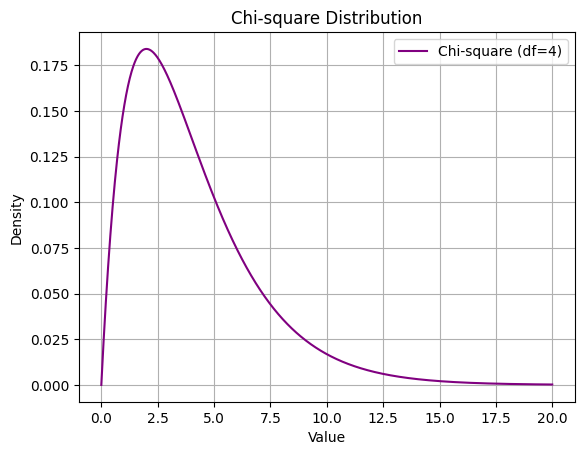

In [26]:
import matplotlib.pyplot as plt

def visualize_chi_square(df=4):
    x = np.linspace(0, 20, 1000)
    y = stats.chi2.pdf(x, df)
    plt.plot(x, y, label=f"Chi-square (df={df})", color='purple')
    plt.title("Chi-square Distribution")
    plt.xlabel("Value")
    plt.ylabel("Density")
    plt.grid(True)
    plt.legend()
    plt.show()

visualize_chi_square()


#  <span style="color:green">16.  Implement an F-test using Python to compare the variances of two random samples.</span>

In [27]:
def f_test_variance(sample1, sample2):
    var1 = np.var(sample1, ddof=1)
    var2 = np.var(sample2, ddof=1)
    f_stat = var1 / var2
    dfn = len(sample1) - 1
    dfd = len(sample2) - 1
    p_value = 1 - stats.f.cdf(f_stat, dfn, dfd)
    return f_stat, p_value


In [28]:
# Example
s1 = np.random.normal(10, 5, 30)
s2 = np.random.normal(10, 2, 30)
print("F-test for Variances:", f_test_variance(s1, s2))

F-test for Variances: (np.float64(4.657490308282739), np.float64(4.2618548457773464e-05))


#  <span style="color:green">17. Write a Python program to perform an ANOVA test to compare means between multiple groups and interpret the results.</span>

In [29]:
def one_way_anova(*groups):
    f_stat, p_value = stats.f_oneway(*groups)
    return f_stat, p_value

# Example
group1 = np.random.normal(100, 10, 30)
group2 = np.random.normal(105, 10, 30)
group3 = np.random.normal(110, 10, 30)
print("One-way ANOVA Test:", one_way_anova(group1, group2, group3))


One-way ANOVA Test: (np.float64(5.359740456912318), np.float64(0.006381274191985514))


#  <span style="color:green">18.  Perform a one-way ANOVA test using Python to compare the means of different groups and plot the results.</span>

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


In [31]:
# Sample data
g1 = np.random.normal(20, 5, 30)
g2 = np.random.normal(22, 5, 30)
g3 = np.random.normal(25, 5, 30)


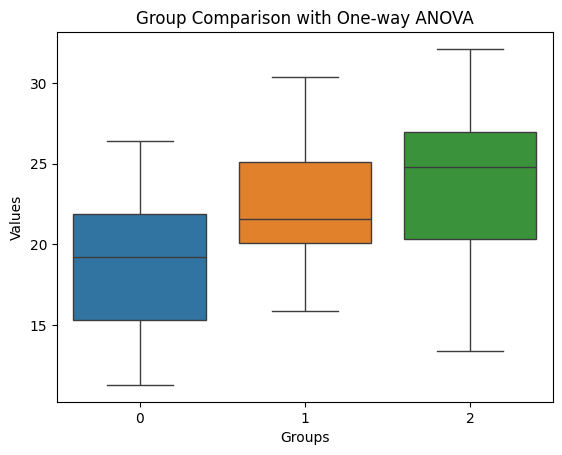

In [32]:
# Boxplot
sns.boxplot(data=[g1, g2, g3])
plt.title("Group Comparison with One-way ANOVA")
plt.xlabel("Groups")
plt.ylabel("Values")
plt.show()


In [33]:

# ANOVA test
f_stat, p_val = stats.f_oneway(g1, g2, g3)
print(f"F-statistic: {f_stat}, p-value: {p_val}")

F-statistic: 10.105108913917029, p-value: 0.00011319147735482927


#  <span style="color:green">19.   Write a Python function to check the assumptions (normality, independence, and equal variance) for ANOVA.</span>

In [34]:
from scipy.stats import shapiro, levene

def check_anova_assumptions(*groups):
    normality = [shapiro(g)[1] > 0.05 for g in groups]
    _, p_var = levene(*groups)
    return {
        "Normality Passed (p > 0.05)": normality,
        "Equal Variance Passed (p > 0.05)": p_var > 0.05,
        "Independence Assumed": True
    }

print(check_anova_assumptions(g1, g2, g3))


{'Normality Passed (p > 0.05)': [np.True_, np.True_, np.True_], 'Equal Variance Passed (p > 0.05)': np.True_, 'Independence Assumed': True}


#  <span style="color:green">20.Perform a two-way ANOVA test using Python to study the interaction between two factors and visualize the results.</span>

In [41]:
!pip install statsmodels


   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.8 MB ? eta -:--:--
   ----- ---------------------------------- 1.3/9.8 MB 4.4 MB/s eta 0:00:02
   --------- ------------------------------ 2.4/9.8 MB 4.6 MB/s eta 0:00:02
   ------------- -------------------------- 3.4/9.8 MB 4.8 MB/s eta 0:00:02
   ------------------ --------------------- 4.5/9.8 MB 4.9 MB/s eta 0:00:02
   ---------------------- ----------------- 5.5/9.8 MB 5.0 MB/s eta 0:00:01
   -------------------------- ------------- 6.6/9.8 MB 5.1 MB/s eta 0:00:01
   ------------------------------ --------- 7.6/9.8 MB 5.1 MB/s eta 0:00:01
   ------------------------------------ --- 8.9/9.8 MB 5.1 MB/s eta 0:00:01
   ---------------------------------------  9.7/9.8 MB 5.1 MB/s eta 0:00:01
   ---------------------------------------- 9.8/9.8 MB 5.0 MB/s eta 0:00:00

   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0


[notice] A new release of pip is available: 24.3.1 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [42]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Simulated data
df = pd.DataFrame({
    'Score': np.random.normal(70, 10, 60),
    'Gender': ['Male']*30 + ['Female']*30,
    'Method': (['A']*15 + ['B']*15)*2
})

model = ols('Score ~ C(Gender) + C(Method) + C(Gender):C(Method)', data=df).fit()
anova_results = sm.stats.anova_lm(model, typ=2)
print(anova_results)


                          sum_sq    df         F    PR(>F)
C(Gender)             357.989595   1.0  4.709823  0.034248
C(Method)               0.044275   1.0  0.000582  0.980831
C(Gender):C(Method)     6.009049   1.0  0.079057  0.779616
Residual             4256.512198  56.0       NaN       NaN


#  <span style="color:green">21.Write a Python program to visualize the F-distribution and discuss its use in hypothesis testing.</span>

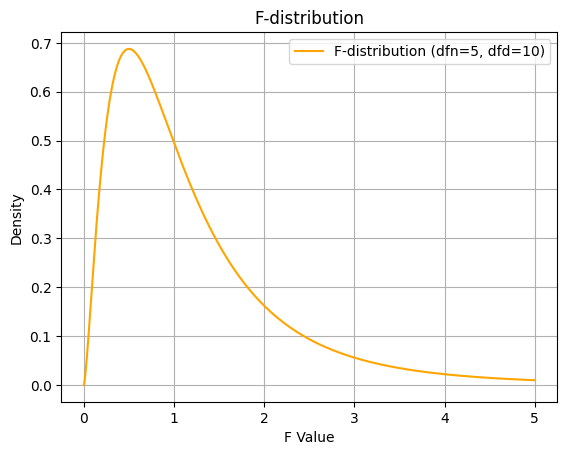

In [37]:
x = np.linspace(0, 5, 1000)
y = stats.f.pdf(x, dfn=5, dfd=10)

plt.plot(x, y, label='F-distribution (dfn=5, dfd=10)', color='orange')
plt.title("F-distribution")
plt.xlabel("F Value")
plt.ylabel("Density")
plt.grid(True)
plt.legend()
plt.show()


#  <span style="color:green">22. Perform a one-way ANOVA test in Python and visualize the results with boxplots to compare group means.</span>

One-way ANOVA results:
F-statistic = 6.271, p-value = 0.0029


C:\Users\Asus\AppData\Local\Temp\ipykernel_14992\1348634164.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group', y='Score', data=df, palette='Set2')


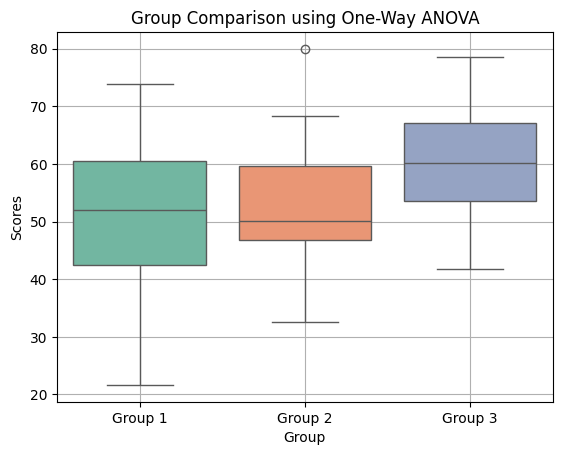

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Step 1: Simulate data for three groups
group1 = np.random.normal(loc=50, scale=10, size=30)
group2 = np.random.normal(loc=55, scale=10, size=30)
group3 = np.random.normal(loc=60, scale=10, size=30)

# Step 2: Combine data into a DataFrame
df = pd.DataFrame({
    'Score': np.concatenate([group1, group2, group3]),
    'Group': ['Group 1'] * 30 + ['Group 2'] * 30 + ['Group 3'] * 30
})

# Step 3: Perform one-way ANOVA
f_stat, p_val = stats.f_oneway(group1, group2, group3)
print(f"One-way ANOVA results:\nF-statistic = {f_stat:.3f}, p-value = {p_val:.4f}")

# Step 4: Visualize results with boxplots
sns.boxplot(x='Group', y='Score', data=df, palette='Set2')
plt.title('Group Comparison using One-Way ANOVA')
plt.ylabel('Scores')
plt.grid(True)
plt.show()


#  <span style="color:green">23.  Simulate random data from a normal distribution, then perform hypothesis testing to evaluate the means.</span>

In [43]:
import numpy as np
from scipy import stats

# Step 1: Simulate a sample from a normal distribution
np.random.seed(0)
sample = np.random.normal(loc=100, scale=15, size=50)  # mean=100, std=15, n=50

# Step 2: Perform a one-sample t-test
# Null Hypothesis H0: population mean = 105
t_stat, p_val = stats.ttest_1samp(sample, popmean=105)

# Step 3: Print the result
print("One-Sample T-Test Result:")
print(f"T-statistic = {t_stat:.3f}")
print(f"P-value = {p_val:.4f}")

# Step 4: Interpret the result
alpha = 0.05
if p_val < alpha:
    print("Reject the null hypothesis: The sample mean is significantly different from 105.")
else:
    print("Fail to reject the null hypothesis: The sample mean is not significantly different from 105.")


One-Sample T-Test Result:
T-statistic = -1.199
P-value = 0.2363
Fail to reject the null hypothesis: The sample mean is not significantly different from 105.


#  <span style="color:green">24.  Perform a hypothesis test for population variance using a Chi-square distribution and interpret the results.</span>

In [44]:
import numpy as np
from scipy import stats

# Step 1: Simulate a sample from a normal distribution
np.random.seed(0)
sample = np.random.normal(loc=100, scale=15, size=50)

# Step 2: Define known population variance under H0
sigma_0 = 15  # hypothesized standard deviation
n = len(sample)
sample_variance = np.var(sample, ddof=1)

# Step 3: Compute the chi-square statistic
chi_square_stat = (n - 1) * sample_variance / (sigma_0 ** 2)

# Step 4: Get p-value (two-tailed test)
p_value = 2 * min(
    stats.chi2.cdf(chi_square_stat, df=n-1),
    1 - stats.chi2.cdf(chi_square_stat, df=n-1)
)

# Step 5: Print result
print("Chi-Square Test for Population Variance:")
print(f"Sample Variance = {sample_variance:.2f}")
print(f"Chi-square Statistic = {chi_square_stat:.3f}")
print(f"P-value = {p_value:.4f}")

# Step 6: Interpretation
alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis: The population variance is significantly different from 225.")
else:
    print("Fail to reject the null hypothesis: No significant difference in population variance.")


Chi-Square Test for Population Variance:
Sample Variance = 290.85
Chi-square Statistic = 63.340
P-value = 0.1635
Fail to reject the null hypothesis: No significant difference in population variance.


#  <span style="color:green">25.  Write a Python script to perform a Z-test for comparing proportions between two datasets or groups.</span>

In [45]:
import numpy as np
from scipy.stats import norm

# Step 1: Define successes and sample sizes
success1, n1 = 45, 100  # Group 1: 45 out of 100
success2, n2 = 40, 100  # Group 2: 40 out of 100

# Step 2: Calculate sample proportions
p1 = success1 / n1
p2 = success2 / n2

# Step 3: Calculate pooled proportion
p_pool = (success1 + success2) / (n1 + n2)

# Step 4: Compute standard error and Z statistic
se = np.sqrt(p_pool * (1 - p_pool) * (1/n1 + 1/n2))
z_stat = (p1 - p2) / se

# Step 5: Compute two-tailed p-value
p_val = 2 * (1 - norm.cdf(abs(z_stat)))

# Step 6: Print the results
print("Z-test for Two Proportions:")
print(f"Proportion 1: {p1:.2f}, Proportion 2: {p2:.2f}")
print(f"Z-statistic = {z_stat:.3f}")
print(f"P-value = {p_val:.4f}")

# Step 7: Interpretation
alpha = 0.05
if p_val < alpha:
    print("Reject the null hypothesis: The two proportions are significantly different.")
else:
    print("Fail to reject the null hypothesis: No significant difference between proportions.")


Z-test for Two Proportions:
Proportion 1: 0.45, Proportion 2: 0.40
Z-statistic = 0.715
P-value = 0.4745
Fail to reject the null hypothesis: No significant difference between proportions.


#  <span style="color:green">26.  Implement an F-test for comparing the variances of two datasets, then interpret and visualize the results.</span>

In [46]:
import numpy as np
from scipy import stats

# Step 1: Simulate two samples with different variances
np.random.seed(0)
group1 = np.random.normal(100, 10, 30)  # std = 10
group2 = np.random.normal(100, 15, 30)  # std = 15

# Step 2: Compute sample variances
var1 = np.var(group1, ddof=1)
var2 = np.var(group2, ddof=1)

# Step 3: Calculate F-statistic (larger variance / smaller variance)
if var1 > var2:
    f_stat = var1 / var2
    dfn, dfd = len(group1)-1, len(group2)-1
else:
    f_stat = var2 / var1
    dfn, dfd = len(group2)-1, len(group1)-1

# Step 4: Two-tailed p-value
p_val = 2 * min(stats.f.cdf(f_stat, dfn, dfd), 1 - stats.f.cdf(f_stat, dfn, dfd))

# Step 5: Print result
print("F-test for Comparing Two Variances:")
print(f"Variance 1 = {var1:.2f}, Variance 2 = {var2:.2f}")
print(f"F-statistic = {f_stat:.3f}")
print(f"P-value = {p_val:.4f}")

# Step 6: Interpretation
alpha = 0.05
if p_val < alpha:
    print("Reject the null hypothesis: The two variances are significantly different.")
else:
    print("Fail to reject the null hypothesis: No significant difference between variances.")


F-test for Comparing Two Variances:
Variance 1 = 121.07, Variance 2 = 188.06
F-statistic = 1.553
P-value = 0.2416
Fail to reject the null hypothesis: No significant difference between variances.


#  <span style="color:green">27.  Perform a Chi-square test for goodness of fit with simulated data and analyze the results.</span>

In [47]:
import numpy as np
from scipy.stats import chisquare

# Step 1: Define observed and expected frequencies
observed = np.array([18, 22, 20])  # Example observed counts
expected = np.array([20, 20, 20])  # Expected counts (uniform distribution)

# Step 2: Perform chi-square goodness-of-fit test
chi2_stat, p_val = chisquare(f_obs=observed, f_exp=expected)

# Step 3: Print the result
print("Chi-Square Goodness-of-Fit Test:")
print(f"Chi-square Statistic = {chi2_stat:.3f}")
print(f"P-value = {p_val:.4f}")

# Step 4: Interpretation
alpha = 0.05
if p_val < alpha:
    print("Reject the null hypothesis: Observed frequencies do not match the expected distribution.")
else:
    print("Fail to reject the null hypothesis: No significant difference between observed and expected frequencies.")


Chi-Square Goodness-of-Fit Test:
Chi-square Statistic = 0.400
P-value = 0.8187
Fail to reject the null hypothesis: No significant difference between observed and expected frequencies.


## <font color='blue'>Thanks for this Assignment</font>